In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn plotly


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

print("We On Go")

We On Go


In [3]:
fg = pd.read_csv('fear_greed_index.csv')
hl = pd.read_csv('historical_data.csv')

print(fg.shape)
print(hl.shape)

(2644, 4)
(211224, 16)


In [4]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
hl.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
print(hl.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [7]:
print(fg.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
print("Trader duplicates:", hl.duplicated().sum())
print("sentiment duplicates:", fg.duplicated().sum())

Trader duplicates: 0
sentiment duplicates: 0


In [9]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
print("Sentiment date sample:", fg['date'].iloc[0], "|type:", type(fg['date'].iloc[0]))
print("Trader date sample:", hl['Timestamp IST'].iloc[0], "| type:", type(hl['Timestamp IST'].iloc[0]))

Sentiment date sample: 2018-02-01 |type: <class 'str'>
Trader date sample: 02-12-2024 22:50 | type: <class 'str'>


In [11]:
fg['date'] = pd.to_datetime(fg['date'])

hl['date'] = pd.to_datetime(hl['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
fg['date'] = fg['date'].dt.date

print("Sentiment date sample:", fg['date'].iloc[0], type(fg['date'].iloc[0]))
print("Trader date sample:", hl['date'].iloc[0], type(hl['date'].iloc[0]))

Sentiment date sample: 2018-02-01 <class 'datetime.date'>
Trader date sample: 2024-12-02 <class 'datetime.date'>


In [12]:
print("Sentiment range:", fg['date'].min(), "→", fg['date'].max())
print("Trader range:", hl['date'].min(), "→", hl['date'].max())

Sentiment range: 2018-02-01 → 2025-05-02
Trader range: 2023-05-01 → 2025-05-01


## Date Alignment
- Sentiment data: 2018-02-01 → 2025-05-02 (2644 days)
- Trader data: 2023-05-01 → 2025-05-01
- Overlap: Full trader history is covered by sentiment data
- Merge strategy: Inner join on date — no trader data will be lost

In [13]:
df = hl.merge(fg[['date', 'classification', 'value']], on='date', how='inner')

print("Before merge:", hl.shape)
print("After merge:", df.shape)
print(df['classification'].value_counts())

Before merge: (211224, 17)
After merge: (211218, 19)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [14]:
mapping = {
    'Extreme Fear' : 'Fear',
    'Fear'         : 'Fear',
    'Neutral'      : 'Neutral',
    'Greed'        : 'Greed',
    'Extreme Greed': 'Greed'
}

df['sentiment'] = df['classification'].map(mapping)
print(df['sentiment'].value_counts())

sentiment
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64


In [15]:
# Directional indicator
df['is_long'] = (df['Side'] == 'BUY').astype(int)

# Position change — adding or reducing exposure
df['position_change'] = df['Size Tokens'] * np.where(df['Side'] == 'BUY', 1, -1)

# Log normalized position — handles whale outliers
df['log_position'] = np.sign(df['Start Position']) * np.log1p(df['Start Position'].abs())

# Implied leverage proxy
df['position_usd'] = df['Start Position'].abs() * df['Execution Price']
df['implied_leverage'] = (df['Size USD'] / df['position_usd'].replace(0, np.nan)).clip(upper=100)

print("Features added. df shape:", df.shape)
print(df[['is_long', 'position_change', 'implied_leverage']].head())

Features added. df shape: (211218, 25)
   is_long  position_change  implied_leverage
0        1           986.87               NaN
1        1            16.00          0.016219
2        1           144.09          0.143728
3        1           142.98          0.124704
4        1             8.73          0.006770


In [16]:
daily = df.groupby(['Account', 'date', 'sentiment']).agg(
    total_pnl       = ('Closed PnL',       'sum'),
    num_trades      = ('Closed PnL',       'count'),
    win_rate        = ('Closed PnL',       lambda x: (x > 0).mean()),
    avg_size_usd    = ('Size USD',         'mean'),
    long_ratio      = ('is_long',          'mean'),
    avg_leverage    = ('implied_leverage', 'mean'),
    position_change = ('position_change',  'sum'),
).reset_index()

daily = daily[daily['total_pnl'] != 0].reset_index(drop=True)

print(daily.shape)
print(daily.head())

(1692, 10)
                                      Account        date sentiment  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22     Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     Greed   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-28     Greed   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-12-06     Greed   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-01-19     Greed   

       total_pnl  num_trades  win_rate  avg_size_usd  long_ratio  \
0  -21227.000000          12  0.000000  28186.666667    1.000000   
1    1603.100000          27  0.444444  17248.148148    0.444444   
2 -132271.000000          82  0.000000  16058.536341    1.000000   
3 -175611.000056          33  0.000000  36736.362424    1.000000   
4   71393.964098         465  0.049462  11410.954022    0.240860   

   avg_leverage  position_change  
0      0.013085     1.000000e+02  
1      0.212463    -4.618528e-14  
2      0.054093     1.300000e+03  
3      0.0190

In [17]:
print(df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'value', 'sentiment', 'is_long', 'position_change', 'log_position', 'position_usd', 'implied_leverage']


In [18]:
print(df['Start Position'].describe())
print(df['Start Position'].value_counts().head(10))
print(df[['Size USD', 'Start Position', 'Execution Price', 'Size Tokens']].head(10))

count    2.112180e+05
mean    -2.994671e+04
std      6.738170e+05
min     -1.433463e+07
25%     -3.760725e+02
50%      8.477051e+01
75%      9.337697e+03
max      3.050948e+07
Name: Start Position, dtype: float64
Start Position
 0.00000      4085
 0.01000       121
 1.00000        83
 50.00000       64
 25.00000       40
 0.00001        37
 10.00000       37
 30.00000       35
-100.00000      34
-1.00000        34
Name: count, dtype: int64
   Size USD  Start Position  Execution Price  Size Tokens
0   7872.16        0.000000           7.9769       986.87
1    127.68      986.524596           7.9800        16.00
2   1150.63     1002.518996           7.9855       144.09
3   1142.04     1146.558564           7.9874       142.98
4     69.75     1289.488521           7.9894         8.73
5     11.27     1298.215466           7.9900         1.41
6   1151.77     1299.624972           7.9934       144.09
7    272.00     1443.664541           8.0000        34.00
8    368.00     1477.652641       

In [19]:
daily['position_change'] = daily['position_change'].round(4)
print(daily['position_change'].describe())

count    1.692000e+03
mean     9.165612e+02
std      5.866187e+05
min     -1.585748e+07
25%     -1.244641e+03
50%      0.000000e+00
75%      7.089474e+02
max      1.359627e+07
Name: position_change, dtype: float64


In [20]:
daily.describe().round(2)

,total_pnl,num_trades,win_rate,avg_size_usd,long_ratio,avg_leverage,position_change
count,1692.00,1692.00,1692.00,1692.00,1692.00,1692.00,1692.00
mean,6060.57,114.92,0.50,6954.69,0.46,0.69,916.56
std,33261.58,245.97,0.31,23823.84,0.30,1.49,586618.71
min,-358963.14,1.00,0.00,3.90,0.00,0.00,-15857478.42
25%,109.66,15.00,0.27,692.70,0.24,0.11,-1244.64
50%,782.75,43.00,0.45,1844.48,0.47,0.26,0.00
75%,3271.91,105.00,0.73,6880.34,0.68,0.64,708.95
max,533974.66,4083.00,1.00,844654.19,1.00,17.56,13596272.81


In [21]:
# Cap PnL at 1st and 99th percentile
pnl_low  = daily['total_pnl'].quantile(0.01)
pnl_high = daily['total_pnl'].quantile(0.99)
daily['total_pnl_capped'] = daily['total_pnl'].clip(lower=pnl_low, upper=pnl_high)

# Cap trade count similarly
trade_high = daily['num_trades'].quantile(0.99)
daily['num_trades_capped'] = daily['num_trades'].clip(upper=trade_high)

# Cap size USD
size_high = daily['avg_size_usd'].quantile(0.99)
daily['avg_size_capped'] = daily['avg_size_usd'].clip(upper=size_high)

print(daily[['total_pnl_capped','num_trades_capped','avg_size_capped']].describe().round(2))

       total_pnl_capped  num_trades_capped  avg_size_capped
count           1692.00            1692.00          1692.00
mean            5321.68             106.35          6145.97
std            19036.08             176.68          9772.96
min           -36266.99               1.00             3.90
25%              109.66              15.00           692.70
50%              782.75              43.00          1844.48
75%             3271.91             105.00          6880.34
max           124516.01             988.36         52482.54


In [22]:
perf = daily.groupby('sentiment').agg(
    avg_pnl    = ('total_pnl_capped', 'mean'),
    median_pnl = ('total_pnl_capped', 'median'),
    avg_winrate= ('win_rate',         'mean'),
    count      = ('total_pnl',        'count')
).round(2)

print(perf)

           avg_pnl  median_pnl  avg_winrate  count
sentiment                                         
Fear       5727.87      662.96         0.49    572
Greed      5246.06      909.46         0.50    844
Neutral    4711.13      567.80         0.48    276


## Insight 1 — Fear Days Produce Bigger Mean Returns, But Greed Days 
## Are Better for the Typical Trader

Mean PnL is highest on Fear days ($5,727) — driven by a small number of 
traders who capitalize on fear-driven dips. However median PnL is highest 
on Greed days ($909), meaning the average trader performs better when 
sentiment is positive. Win rates are nearly identical (~49-50%) across all 
sentiment regimes, suggesting sentiment affects trade SIZE and TIMING more 
than trade QUALITY.

/var/folders/1v/tkn7f5v536n1lfgnt804dtkm0000gn/T/ipykernel_15931/3486596381.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily, x='sentiment', y='total_pnl_capped',


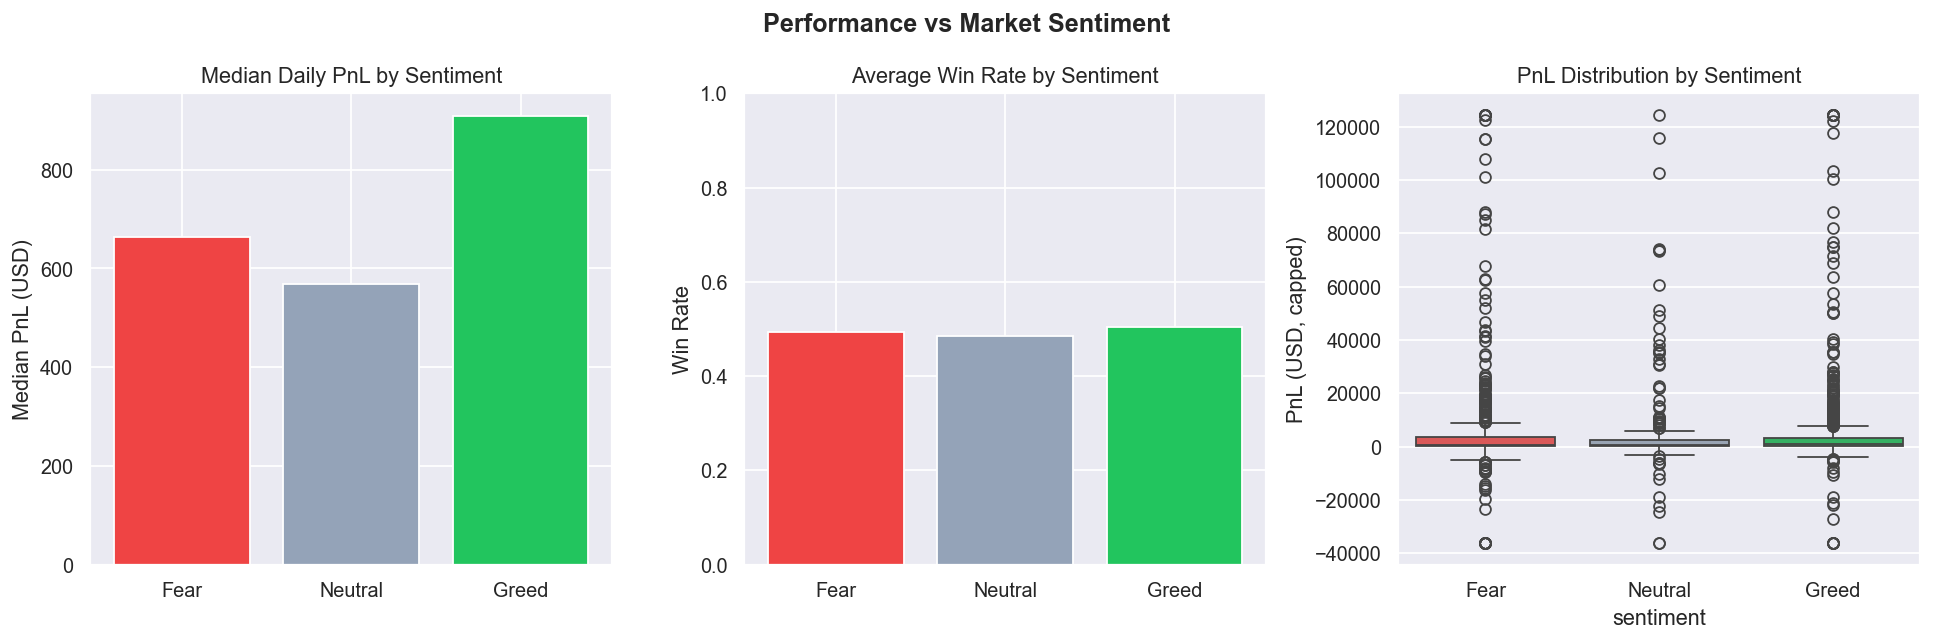

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'Fear': '#ef4444', 'Greed': '#22c55e', 'Neutral': '#94a3b8'}
order  = ['Fear', 'Neutral', 'Greed']

# Chart 1 — Median PnL by sentiment::
medians = daily.groupby('sentiment')['total_pnl_capped'].median().reindex(order)
axes[0].bar(medians.index, medians.values,
            color=[colors[s] for s in medians.index])
axes[0].set_title('Median Daily PnL by Sentiment')
axes[0].set_ylabel('Median PnL (USD)')

# Chart 2 — Win Rate by sentiment::
winrates = daily.groupby('sentiment')['win_rate'].mean().reindex(order)
axes[1].bar(winrates.index, winrates.values,
            color=[colors[s] for s in winrates.index])
axes[1].set_title('Average Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate')
axes[1].set_ylim(0, 1)

# Chart 3 — PnL distribution boxplot::
sns.boxplot(data=daily, x='sentiment', y='total_pnl_capped',
            order=order, palette=colors, ax=axes[2])
axes[2].set_title('PnL Distribution by Sentiment')
axes[2].set_ylabel('PnL (USD, capped)')

plt.suptitle('Performance vs Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_performance_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight 2 — Fear Days Are High Risk, High Reward

The PnL distribution on Fear days is significantly wider than Greed or 
Neutral days. This means Fear days produce both the biggest winners and 
biggest losers. Greed days show a tighter, more consistent distribution — 
suggesting calmer, more predictable market conditions for traders.

In [24]:
behavior = daily.groupby('sentiment').agg(
    avg_trades    = ('num_trades_capped', 'mean'),
    avg_size      = ('avg_size_capped',   'mean'),
    avg_long_pct  = ('long_ratio',        'mean'),
    avg_pos_change= ('position_change',   'median'),
).round(3)

print(behavior)

           avg_trades  avg_size  avg_long_pct  avg_pos_change
sentiment                                                    
Fear          122.695  6803.176         0.477             0.0
Greed          94.142  5632.949         0.449             0.0
Neutral       109.814  6352.767         0.474             0.0


## Insight 3 — Traders Are More Active and Aggressive on Fear Days

Contrary to expectations, traders execute 30% more trades on Fear days 
(122 vs 94) and use 20% larger position sizes ($6,803 vs $5,632). This 
suggests experienced Hyperliquid traders treat fear-driven volatility as 
opportunity rather than risk. Long bias remains consistent (~47%) across 
all sentiment regimes, indicating these traders are not simple momentum 
followers.

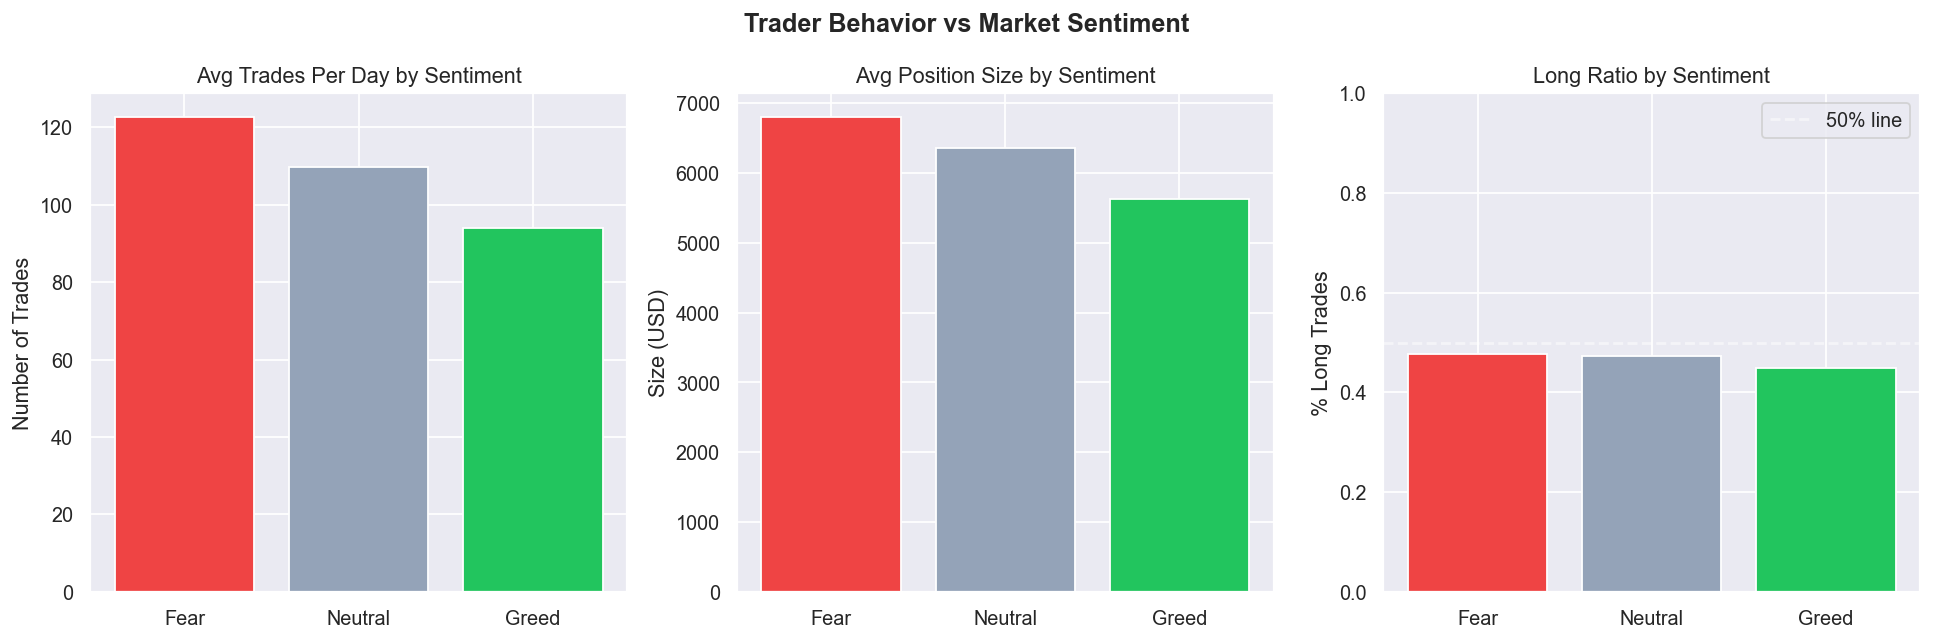

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
order  = ['Fear', 'Neutral', 'Greed']
colors = {'Fear': '#ef4444', 'Greed': '#22c55e', 'Neutral': '#94a3b8'}

# Chart 1 — Trade frequency
trades = daily.groupby('sentiment')['num_trades_capped'].mean().reindex(order)
axes[0].bar(trades.index, trades.values,
            color=[colors[s] for s in trades.index])
axes[0].set_title('Avg Trades Per Day by Sentiment')
axes[0].set_ylabel('Number of Trades')

# Chart 2 — Position size
sizes = daily.groupby('sentiment')['avg_size_capped'].mean().reindex(order)
axes[1].bar(sizes.index, sizes.values,
            color=[colors[s] for s in sizes.index])
axes[1].set_title('Avg Position Size by Sentiment')
axes[1].set_ylabel('Size (USD)')

# Chart 3 — Long ratio
longs = daily.groupby('sentiment')['long_ratio'].mean().reindex(order)
axes[2].bar(longs.index, longs.values,
            color=[colors[s] for s in longs.index])
axes[2].set_title('Long Ratio by Sentiment')
axes[2].set_ylabel('% Long Trades')
axes[2].set_ylim(0, 1)
axes[2].axhline(0.5, color='white', linestyle='--', alpha=0.5, label='50% line')
axes[2].legend()

plt.suptitle('Trader Behavior vs Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_behavior_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
trader = daily.groupby('Account').agg(
    total_pnl      = ('total_pnl',        'sum'),
    avg_daily_pnl  = ('total_pnl',        'mean'),
    pnl_std        = ('total_pnl',        'std'),
    avg_win_rate   = ('win_rate',         'mean'),
    avg_trades     = ('num_trades',       'mean'),
    total_days     = ('date',             'nunique'),
    avg_size       = ('avg_size_usd',     'mean'),
    avg_long_ratio = ('long_ratio',       'mean'),
).reset_index()

trader['pnl_std'] = trader['pnl_std'].fillna(0)

print(trader.shape)
print(trader.describe().round(2))

(32, 9)
        total_pnl  avg_daily_pnl    pnl_std  avg_win_rate  avg_trades  \
count       32.00          32.00      32.00         32.00       32.00   
mean    320452.72       12238.42   28221.72          0.54      136.99   
std     494659.65       20279.82   35740.79          0.13      170.95   
min    -167621.12       -6403.29     947.94          0.37       13.50   
25%      46893.24         835.74    4847.20          0.44       44.30   
50%     117655.08        2941.85   13582.94          0.51       79.46   
75%     388457.02       15900.98   40451.36          0.61      150.79   
max    2143382.60       84222.62  165361.20          0.86      869.74   

       total_days  avg_size  avg_long_ratio  
count       32.00     32.00           32.00  
mean        52.88   9082.31            0.44  
std         56.13   9663.90            0.15  
min          7.00    483.92            0.07  
25%         17.25   2281.12            0.38  
50%         26.00   6228.12            0.45  
75%         

In [27]:
freq_median = trader['avg_trades'].median()
trader['freq_seg'] = trader['avg_trades'].apply(
    lambda x: 'High Frequency' if x > freq_median else 'Low Frequency')

size_median = trader['avg_size'].median()
trader['size_seg'] = trader['avg_size'].apply(
    lambda x: 'High Size' if x > size_median else 'Low Size')

trader['pnl_cv'] = trader['pnl_std'] / (trader['avg_daily_pnl'].abs() + 1)
cv_median = trader['pnl_cv'].median()
trader['consistency_seg'] = trader['pnl_cv'].apply(
    lambda x: 'Consistent' if x < cv_median else 'Volatile')

print(trader['freq_seg'].value_counts())
print(trader['size_seg'].value_counts())
print(trader['consistency_seg'].value_counts())

freq_seg
High Frequency    16
Low Frequency     16
Name: count, dtype: int64
size_seg
High Size    16
Low Size     16
Name: count, dtype: int64
consistency_seg
Consistent    16
Volatile      16
Name: count, dtype: int64


In [28]:
print("Unique traders:", trader.shape[0])
print(trader.describe().round(2))

Unique traders: 32
        total_pnl  avg_daily_pnl    pnl_std  avg_win_rate  avg_trades  \
count       32.00          32.00      32.00         32.00       32.00   
mean    320452.72       12238.42   28221.72          0.54      136.99   
std     494659.65       20279.82   35740.79          0.13      170.95   
min    -167621.12       -6403.29     947.94          0.37       13.50   
25%      46893.24         835.74    4847.20          0.44       44.30   
50%     117655.08        2941.85   13582.94          0.51       79.46   
75%     388457.02       15900.98   40451.36          0.61      150.79   
max    2143382.60       84222.62  165361.20          0.86      869.74   

       total_days  avg_size  avg_long_ratio  pnl_cv  
count       32.00     32.00           32.00   32.00  
mean        52.88   9082.31            0.44    5.17  
std         56.13   9663.90            0.15    7.48  
min          7.00    483.92            0.07    0.70  
25%         17.25   2281.12            0.38    1.68  

In [29]:
freq_median = trader['avg_trades'].median()
trader['freq_seg'] = trader['avg_trades'].apply(
    lambda x: 'High Frequency' if x > freq_median else 'Low Frequency')

size_median = trader['avg_size'].median()
trader['size_seg'] = trader['avg_size'].apply(
    lambda x: 'High Size' if x > size_median else 'Low Size')

trader['pnl_cv'] = trader['pnl_std'] / (trader['avg_daily_pnl'].abs() + 1)
cv_median = trader['pnl_cv'].median()
trader['consistency_seg'] = trader['pnl_cv'].apply(
    lambda x: 'Consistent' if x < cv_median else 'Volatile')

print(trader[['freq_seg','size_seg','consistency_seg']].value_counts())

freq_seg        size_seg   consistency_seg
High Frequency  High Size  Consistent         7
Low Frequency   Low Size   Volatile           6
High Frequency  Low Size   Volatile           4
Low Frequency   Low Size   Consistent         4
High Frequency  High Size  Volatile           3
Low Frequency   High Size  Consistent         3
                           Volatile           3
High Frequency  Low Size   Consistent         2
Name: count, dtype: int64


In [30]:
trader = daily.groupby('Account').agg(
    total_pnl      = ('total_pnl',    'sum'),
    avg_daily_pnl  = ('total_pnl',    'mean'),
    pnl_std        = ('total_pnl',    'std'),
    avg_win_rate   = ('win_rate',     'mean'),
    avg_trades     = ('num_trades',   'mean'),
    total_days     = ('date',         'nunique'),
    avg_size       = ('avg_size_usd', 'mean'),
    avg_long_ratio = ('long_ratio',   'mean'),
).reset_index()

trader['pnl_std']  = trader['pnl_std'].fillna(0)

freq_median = trader['avg_trades'].median()
trader['freq_seg'] = trader['avg_trades'].apply(
    lambda x: 'High Frequency' if x > freq_median else 'Low Frequency')

size_median = trader['avg_size'].median()
trader['size_seg'] = trader['avg_size'].apply(
    lambda x: 'High Size' if x > size_median else 'Low Size')

trader['pnl_cv'] = trader['pnl_std'] / (trader['avg_daily_pnl'].abs() + 1)
cv_median = trader['pnl_cv'].median()
trader['consistency_seg'] = trader['pnl_cv'].apply(
    lambda x: 'Consistent' if x < cv_median else 'Volatile')

print("Trader segments built:")
print(trader[['freq_seg','size_seg','consistency_seg']].value_counts())

Trader segments built:
freq_seg        size_seg   consistency_seg
High Frequency  High Size  Consistent         7
Low Frequency   Low Size   Volatile           6
High Frequency  Low Size   Volatile           4
Low Frequency   Low Size   Consistent         4
High Frequency  High Size  Volatile           3
Low Frequency   High Size  Consistent         3
                           Volatile           3
High Frequency  Low Size   Consistent         2
Name: count, dtype: int64


In [31]:
cols_to_drop = [c for c in daily.columns if 'seg' in c]
daily = daily.drop(columns=cols_to_drop)

daily = daily.merge(
    trader[['Account', 'freq_seg', 'size_seg', 'consistency_seg']],
    on='Account',
    how='left'
)

print("Merge successful. Shape:", daily.shape)
print("Columns:", daily.columns.tolist())

Merge successful. Shape: (1692, 16)
Columns: ['Account', 'date', 'sentiment', 'total_pnl', 'num_trades', 'win_rate', 'avg_size_usd', 'long_ratio', 'avg_leverage', 'position_change', 'total_pnl_capped', 'num_trades_capped', 'avg_size_capped', 'freq_seg', 'size_seg', 'consistency_seg']


In [32]:
print(daily.columns.tolist())

['Account', 'date', 'sentiment', 'total_pnl', 'num_trades', 'win_rate', 'avg_size_usd', 'long_ratio', 'avg_leverage', 'position_change', 'total_pnl_capped', 'num_trades_capped', 'avg_size_capped', 'freq_seg', 'size_seg', 'consistency_seg']


In [33]:
seg_perf = daily.groupby(['consistency_seg', 'sentiment'])['total_pnl_capped'].median().unstack()
print("Consistent vs Volatile by Sentiment:")
print(seg_perf.round(2))
 
freq_perf = daily.groupby(['freq_seg', 'sentiment'])['total_pnl_capped'].median().unstack()
print("\nHigh vs Low Frequency by Sentiment:")
print(freq_perf.round(2))

size_perf = daily.groupby(['size_seg', 'sentiment'])['total_pnl_capped'].median().unstack()
print("\nHigh vs Low Size by Sentiment:")
print(size_perf.round(2))

Consistent vs Volatile by Sentiment:
sentiment           Fear    Greed  Neutral
consistency_seg                           
Consistent       2090.84  1966.93  1183.04
Volatile          430.01   698.01   410.67

High vs Low Frequency by Sentiment:
sentiment         Fear   Greed  Neutral
freq_seg                               
High Frequency  625.51  907.71   465.05
Low Frequency   781.67  910.17   619.57

High vs Low Size by Sentiment:
sentiment     Fear    Greed  Neutral
size_seg                            
High Size  2514.69  1302.92  1829.29
Low Size    400.90   768.43   401.71


## Insight 4 — Consistency Beats Volatility in Every Market Condition
Consistent traders (low PnL variance) outperform volatile traders 4.8x on 
Fear days and 2.8x on Greed days. Discipline is more valuable than 
aggression regardless of sentiment.

## Insight 5 — Less Trading = Better Performance on Fear Days
Low frequency traders outperform high frequency traders on Fear days 
($781 vs $625). Overtrading during fear-driven volatility hurts performance.

## Insight 6 — Large Position Traders Thrive on Fear, Not Greed
High size traders earn 3.1x more on Fear days vs Low size traders, but 
only 1.7x more on Greed days. Large position sizing is most rewarded 
when markets are fearful.

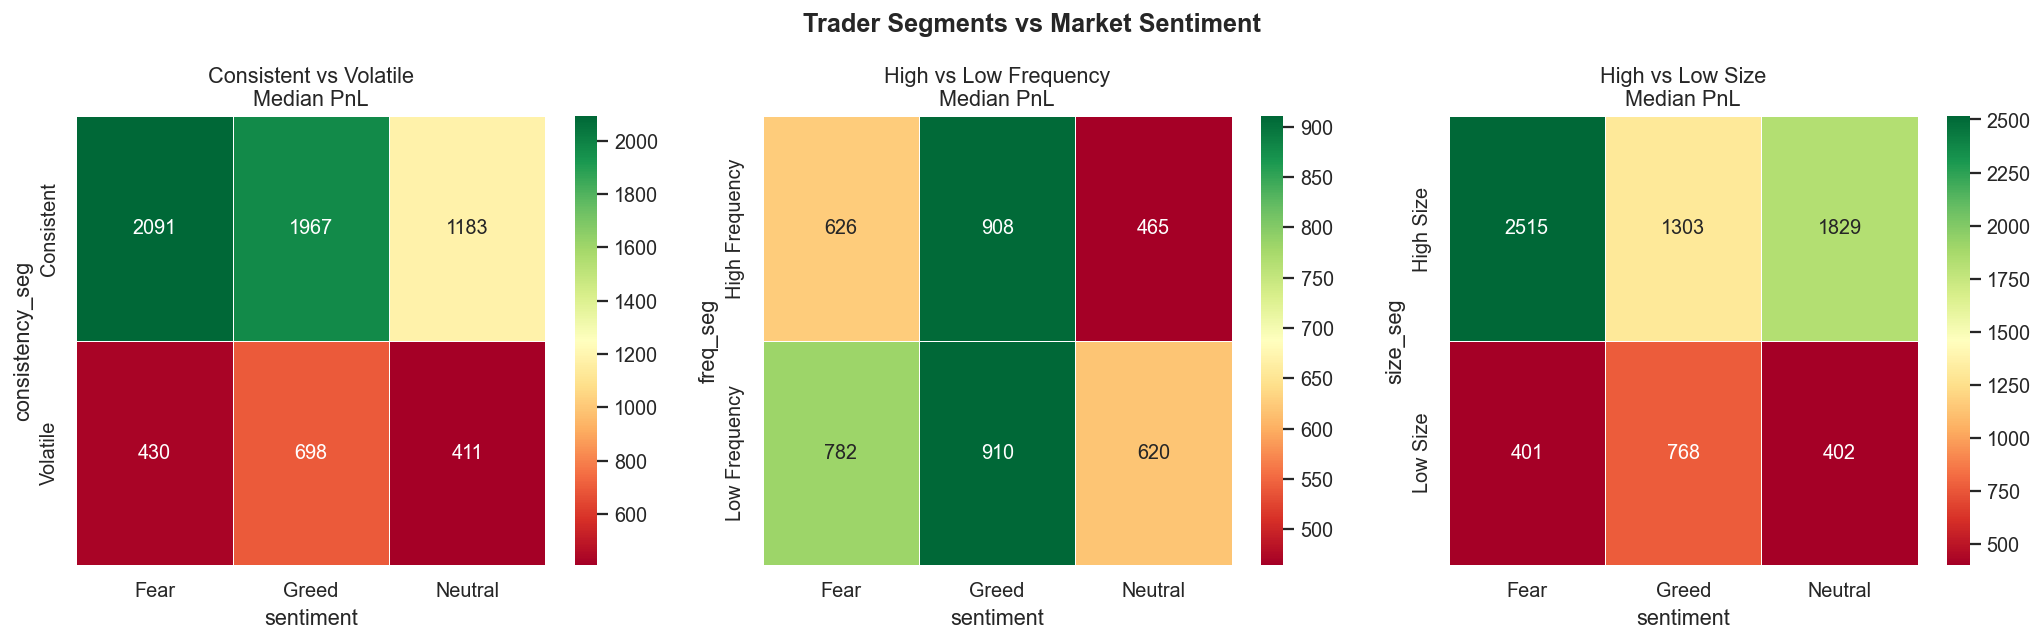

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.heatmap(seg_perf, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Consistent vs Volatile\nMedian PnL')

sns.heatmap(freq_perf, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('High vs Low Frequency\nMedian PnL')

sns.heatmap(size_perf, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[2])
axes[2].set_title('High vs Low Size\nMedian PnL')

plt.suptitle('Trader Segments vs Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_segments_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Part C — Strategy Recommendations

### Strategy 1 — "Fear Day Sizing Rule"
Finding: High Size traders earn $2,514 median PnL on Fear days vs $400 
for Low Size traders — a 6.3x difference. Consistent traders earn $2,090 
on Fear days vs $430 for Volatile traders.

Rule: "On Fear days, consistent traders with proven track records should 
increase position sizes. Volatile traders should reduce exposure entirely 
on Fear days — their median PnL of $430 does not justify the risk."

IF sentiment = Fear AND consistency_seg = Consistent → increase size
IF sentiment = Fear AND consistency_seg = Volatile → reduce size to minimum

### Strategy 2 — "Greed Day Frequency Cap"
Finding: Low frequency traders match high frequency traders on Greed days 
($910 vs $907) while outperforming them on Fear days ($781 vs $625). 
More trades do not produce more profit.

Rule: "All trader segments should cap daily trade frequency on Fear days. 
High frequency traders especially should reduce trade count — the data 
shows no performance benefit from overtrading, and increased activity 
during volatile conditions increases fee drag and execution risk."

IF sentiment = Fear AND freq_seg = High Frequency → cap trades at median
IF sentiment = Greed → maintain normal frequency, no edge from increasing

### Limitations
- Only 32 unique traders — findings directional, not statistically conclusive
- Leverage data unavailable — implied proxy used
- Past sentiment-behavior patterns may not persist in future market regimes
- Recommendation: recalibrate segments on rolling 90-day window in production

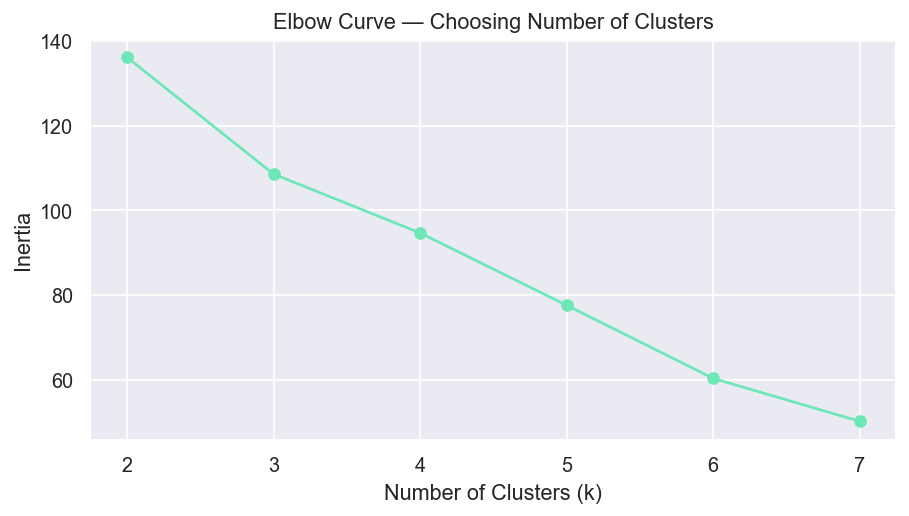

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

features = ['avg_daily_pnl', 'pnl_std', 'avg_win_rate', 
            'avg_trades', 'avg_size', 'avg_long_ratio']

X = trader[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find best k using elbow method
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), inertias, marker='o', color='#6ee7b7')
plt.title('Elbow Curve — Choosing Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.savefig('chart4_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
trader['cluster'] = km_final.fit_predict(X_scaled)

cluster_profile = trader.groupby('cluster')[features].mean().round(2)
print(cluster_profile)

         avg_daily_pnl    pnl_std  avg_win_rate  avg_trades  avg_size  \
cluster                                                                 
0             65964.40  139973.59          0.44      145.71  19502.38   
1              3976.00   16186.14          0.46      133.59  10053.93   
2             45133.43   57285.05          0.63      470.39  13956.15   
3              5670.84   17612.84          0.68       41.00   3884.37   

         avg_long_ratio  
cluster                  
0                  0.58  
1                  0.47  
2                  0.33  
3                  0.41  


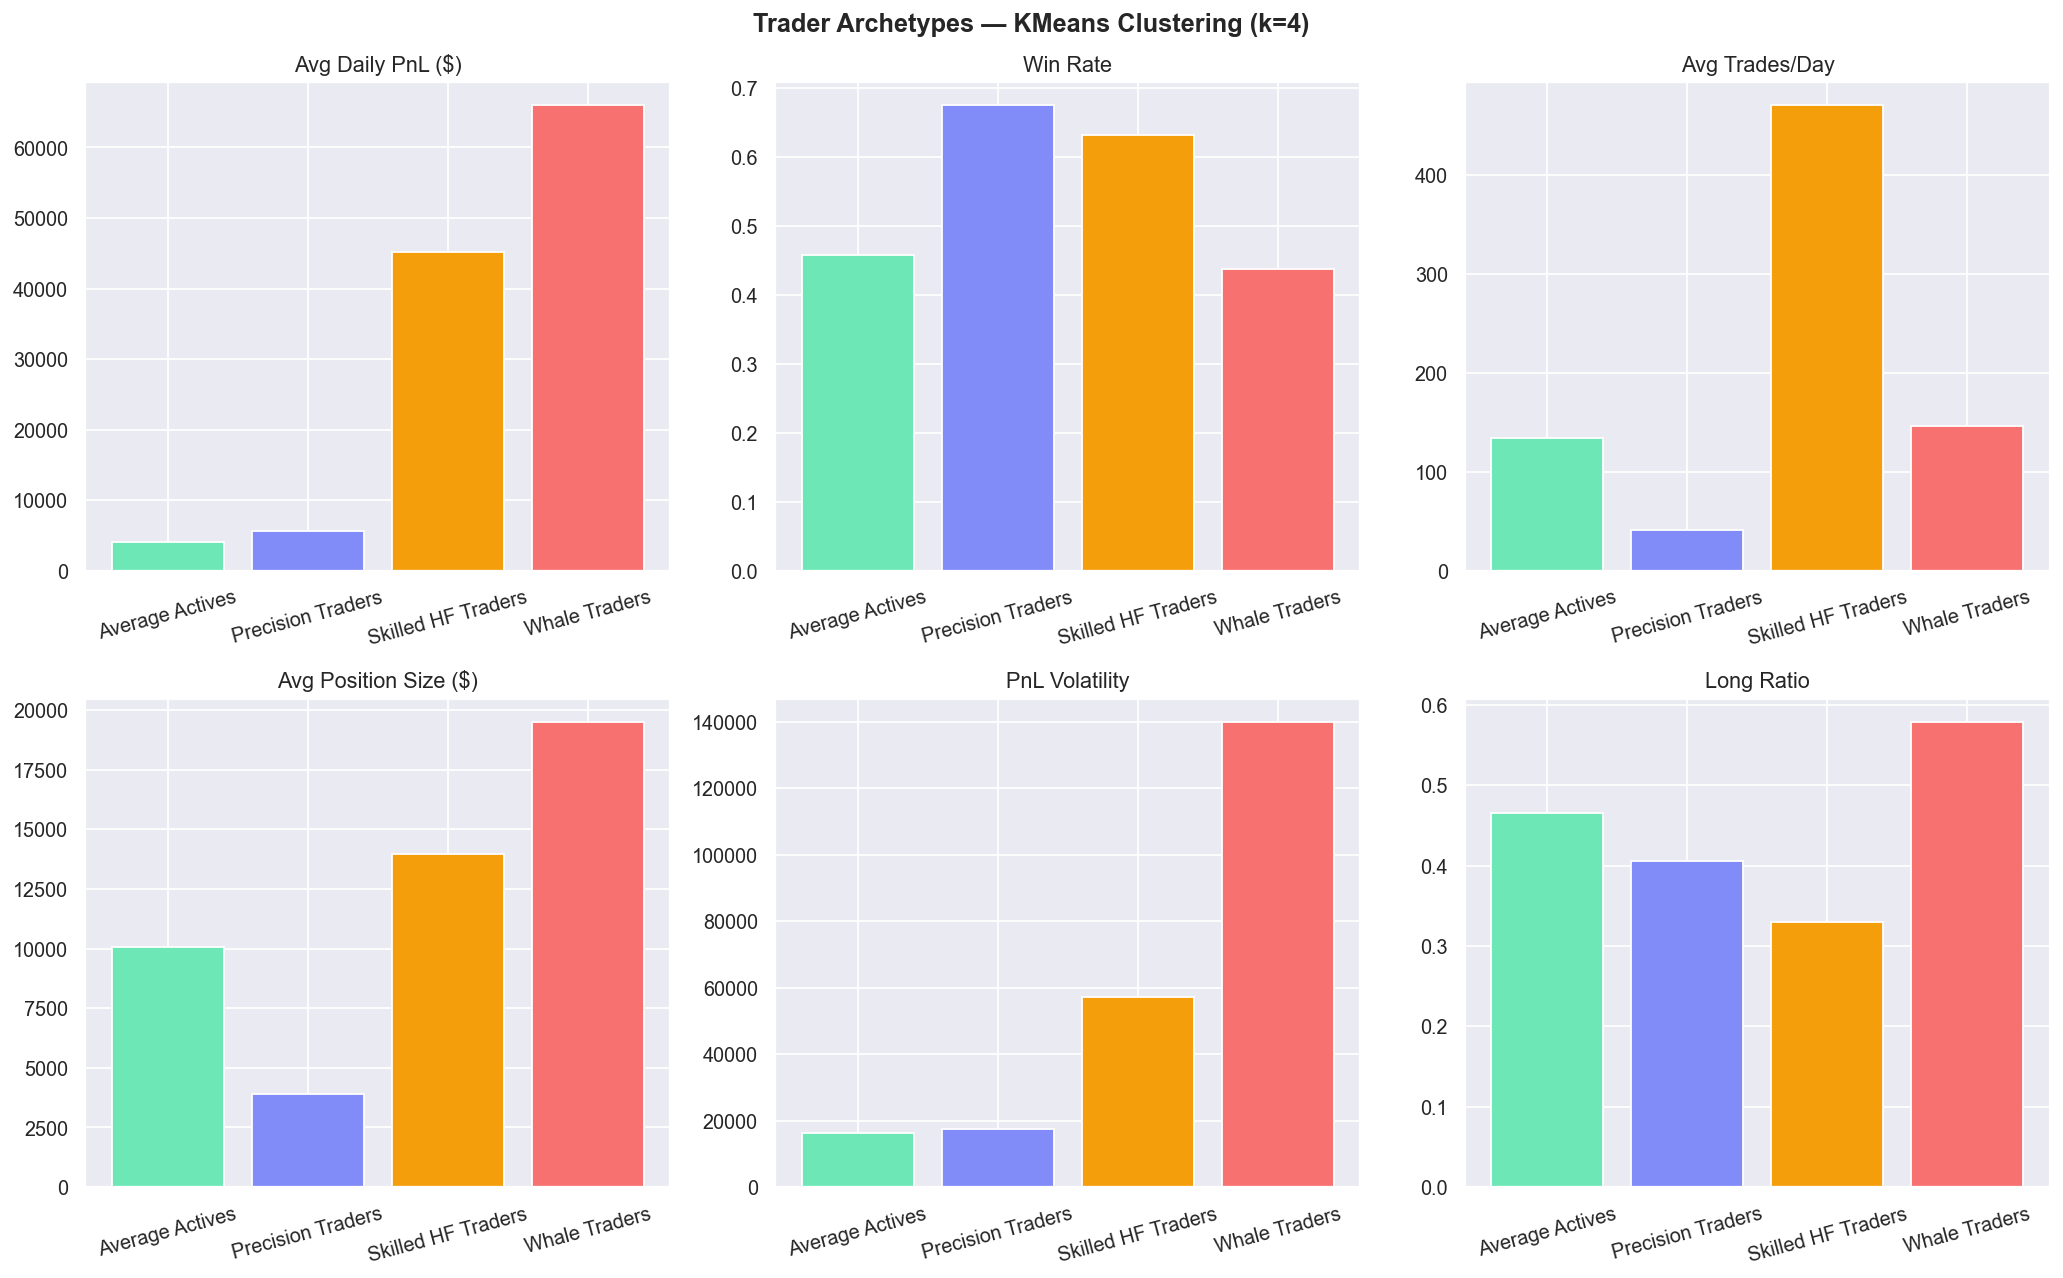

In [37]:
cluster_names = {
    0: 'Whale Traders',
    1: 'Average Actives',
    2: 'Skilled HF Traders',
    3: 'Precision Traders'
}
trader['cluster_name'] = trader['cluster'].map(cluster_names)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = [
    ('avg_daily_pnl',  'Avg Daily PnL ($)'),
    ('avg_win_rate',   'Win Rate'),
    ('avg_trades',     'Avg Trades/Day'),
    ('avg_size',       'Avg Position Size ($)'),
    ('pnl_std',        'PnL Volatility'),
    ('avg_long_ratio', 'Long Ratio'),
]

colors = ['#6ee7b7', '#818cf8', '#f59e0b', '#f87171']

for ax, (col, label) in zip(axes.flatten(), metrics):
    values = trader.groupby('cluster_name')[col].mean()
    ax.bar(values.index, values.values, color=colors)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Trader Archetypes — KMeans Clustering (k=4)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_clusters.png', dpi=150, bbox_inches='tight')
plt.show()